In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

df = pd.read_csv("Loan_default.csv")
X = df[["Income"]]
y = df["LoanAmount"]

df_sample = df.sample(2500, random_state=42)

X = df_sample[["Income"]]
y = df_sample["LoanAmount"]
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

X_curve = np.linspace( X["Income"].min(), X["Income"].max(),300).reshape(-1, 1)
X_curve_poly = poly.transform(X_curve)
y_curve = model.predict(X_curve_poly)


D:\B.E DU\SEM - 5\ML\Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [23]:
print(model.score(X_curve_poly, y_curve))

1.0


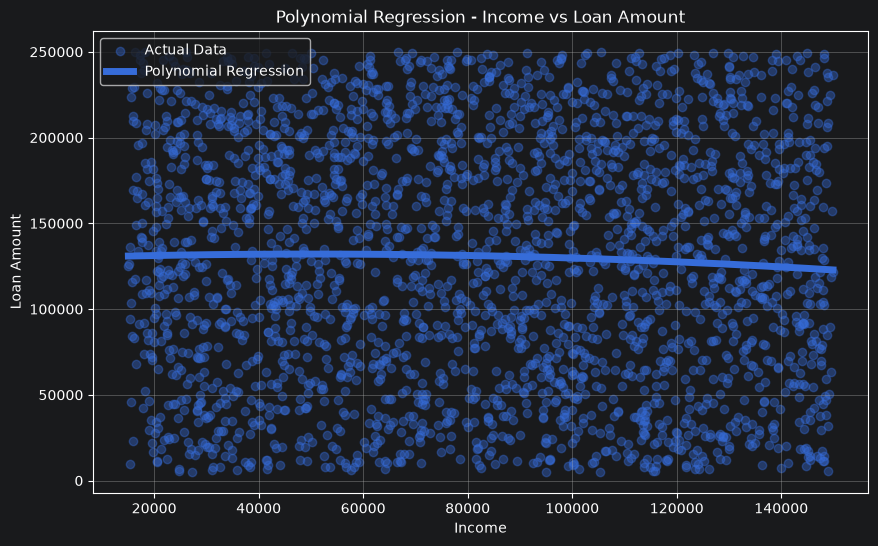

In [24]:
plt.figure(figsize=(10, 6))

plt.scatter(X["Income"], y, alpha=0.4, label="Actual Data")
plt.plot( X_curve, y_curve, linewidth=5, label="Polynomial Regression")
plt.xlabel("Income")
plt.ylabel("Loan Amount")
plt.title("Polynomial Regression - Income vs Loan Amount")
plt.legend()
plt.grid(True)

plt.show()

In [25]:

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

df_sample = df.sample(3000, random_state=42)
X = df_sample[["Income"]]
y = df_sample["LoanAmount"]

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).ravel()

model = SVR( kernel="rbf", C=100, gamma="scale")
model.fit(X_scaled, y_scaled)

X_curve = np.linspace( X["Income"].min(), X["Income"].max(), 300).reshape(-1, 1)
X_curve_scaled = scaler_X.transform(X_curve)
y_curve_scaled = model.predict(X_curve_scaled)
y_curve = scaler_y.inverse_transform( y_curve_scaled.reshape(-1, 1)).ravel()



D:\B.E DU\SEM - 5\ML\Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


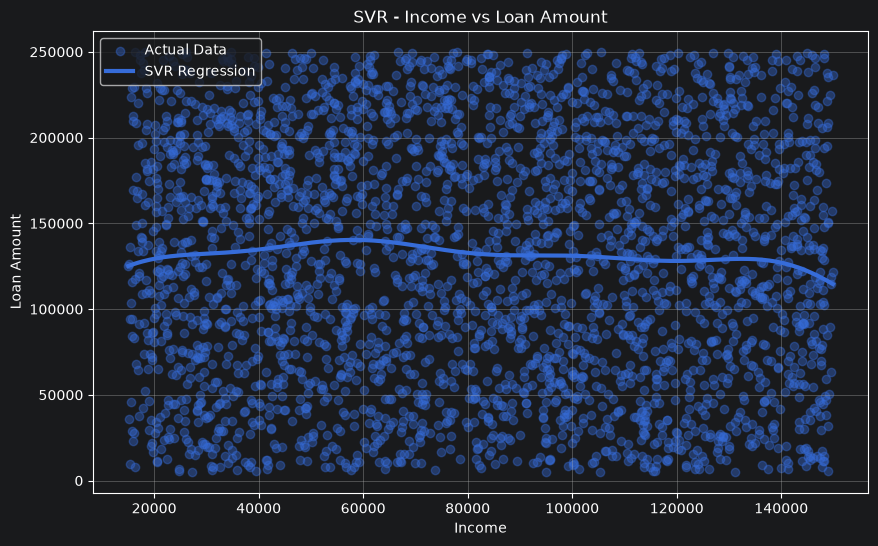

In [26]:
plt.figure(figsize=(10, 6))

plt.scatter( X["Income"], y, alpha=0.4, label="Actual Data")

plt.plot( X_curve, y_curve, linewidth=3, label="SVR Regression" )
plt.xlabel("Income")
plt.ylabel("Loan Amount")
plt.title("SVR - Income vs Loan Amount")
plt.legend()
plt.grid(True)

plt.show()

In [29]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
y_pred_scaled = model.predict(X_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
variance = np.var(y - y_pred)

print(f"R² (Coefficient of Determination): {r2:.4f}")
print(f"MAE (Mean Absolute Error): {mae:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"Variance (Error Variance): {variance:.4f}")

ValueError: X has 1 features, but LinearRegression is expecting 4 features as input.